# Final Project NLP

Mateo Galvis L

## 1. Packages

In [1]:
! pip install gensim
! pip install pyLDAvis
#! pip install --upgrade pyLDAvis gensim jupyter_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 30.9 MB/s eta 0:00:00


In [2]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import spacy
import pickle
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

# LDA imports
from gensim.models.phrases import Phrases, Phraser
from gensim.corpora import Dictionary

import multiprocessing
from gensim.models import LdaMulticore
from gensim.models.coherencemodel import CoherenceModel
import random

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [4]:
from google.colab import drive
# Contect to your drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Read data

In [5]:
#df_news_AI = pd.read_parquet('https://storage.googleapis.com/msca-bdp-data-open/news_final_project/news_final_project.parquet', engine='pyarrow')
df_news_AI_clean = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/Final Project NLP/df_news_clean.parquet', engine='pyarrow')

In [6]:
display(df_news_AI_clean.head(10))

,url,date,title,text,year,month,text_word_count,title_word_count,clean_title,clean_text,title_word_clean_count,text_word_clean_count,title_text_clean,title_text_clean_count,semantic_score
0,https://blockworks.co/price/bad,2025-06-23,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod...",2025,6,483,14,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",Open menuBrandsnewsletterspodcastseventsroundt...,12,470,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",482,0.205120
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,This AI video of gymnastics might be the freak...,\n\nThis AI video of gymnastics might be the f...,2024,7,812,15,This AI video of gymnastics might be the freak...,"\nJennifer Sandlin\n5:13 am Mon\nJul 1, 2024\n...",12,724,This AI video of gymnastics might be the freak...,736,0.282888
2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,"If using AI feels like a chore, try this - Boi...","\n\nIf using AI feels like a chore, try this -...",2024,9,884,12,"If using AI feels like a chore, try this","\nBoing Boing's Shop\n8:00 am Wed\nSep 18, 202...",9,802,"If using AI feels like a chore, try this \nBoi...",811,0.378478
3,https://citylife.capetown/gl/uncategorized/the...,2023-11-10,The Road Ahead: How China's AI Foundation Mode...,The Road Ahead: How China's AI Foundation M...,2023,11,596,16,The Road Ahead: How China's AI Foundation Mode...,\nIr ao contidoVen. 10 de novembro de 2023 Vid...,16,580,The Road Ahead: How China's AI Foundation Mode...,596,0.449198
4,https://citylife.capetown/kk/uncategorized/mic...,2023-11-19,Microsoft and Nvidia to Empower Developers wit...,Microsoft and Nvidia to Empower Developers ...,2023,11,622,10,Microsoft and Nvidia to Empower Developers wit...,"\nByМамфо Брешиа\nҚараша 15, 2023\nMicrosoft a...",10,587,Microsoft and Nvidia to Empower Developers wit...,597,0.312896
5,https://citylife.capetown/lb/uncategorized/how...,2023-12-12,Google Releases New Chatbot Bard as a Strong C...,Google Releases New Chatbot Bard as a Strong ...,2023,12,382,12,Google Releases New Chatbot Bard as a Strong C...,\nWiessel un InhaltDi. 12 Dezember 2023 Stad L...,12,370,Google Releases New Chatbot Bard as a Strong C...,382,0.428753
6,https://citylife.capetown/technology/zoom-laun...,2023-09-07,Zoom Expands AI Offering with AI Companion and...,Zoom Expands AI Offering with AI Companion an...,2023,9,552,10,Zoom Expands AI Offering with AI Companion and...,"\nByRobert Andrew\nSep 7, 2023\nZoom Video Com...",10,516,Zoom Expands AI Offering with AI Companion and...,526,0.430088
7,https://citylife.capetown/uncategorized/pro-ai...,2023-08-04,Pro-AI Thinking: Enhancing Industrial Environm...,\n\nPro-AI Thinking: Enhancing Industrial Envi...,2023,8,533,8,Pro-AI Thinking: Enhancing Industrial Environm...,"\nByMampho Brescia\nAug 4, 2023\nIn the rapidl...",8,294,Pro-AI Thinking: Enhancing Industrial Environm...,302,0.598093
8,https://clickup.com/ai/prompts/business-risk-m...,2024-03-13,Best AI Prompts for Business Risk Management,Best AI Prompts for Business Risk ManagementPr...,2024,3,1040,7,Best AI Prompts for Business Risk Management,Mitigate risks and protect your business with ...,7,986,Best AI Prompts for Business Risk Management M...,993,0.519313
9,https://crooksandliars.com/2025/12/state-ags-w...,2025-12-15,State AGs Warn AI Companies: Clean Up Your Chi...,\nState AGs Warn AI Companies: Clean Up Your C...,2025,12,1051,14,State AGs Warn AI Companies: Clean Up Your Chi...,\nThe letter then lists disturbing and alleged...,10,928,State AGs Warn AI Companies: Clean Up Your Chi...,938,0.313602


In [7]:
print('Initial dataframe shape :', df_news_AI_clean.shape)
print('Columns in the dataframe :', df_news_AI_clean.columns)

Initial dataframe shape : (186029, 15)
Columns in the dataframe : Index(['url', 'date', 'title', 'text', 'year', 'month', 'text_word_count',
       'title_word_count', 'clean_title', 'clean_text',
       'title_word_clean_count', 'text_word_clean_count', 'title_text_clean',
       'title_text_clean_count', 'semantic_score'],
      dtype='object')


In [8]:
display(df_news_AI_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186029 entries, 0 to 186028
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   url                     186029 non-null  object        
 1   date                    186029 non-null  datetime64[ns]
 2   title                   186029 non-null  object        
 3   text                    186029 non-null  object        
 4   year                    186029 non-null  int32         
 5   month                   186029 non-null  int32         
 6   text_word_count         186029 non-null  int64         
 7   title_word_count        186029 non-null  int64         
 8   clean_title             186029 non-null  object        
 9   clean_text              186029 non-null  object        
 10  title_word_clean_count  186029 non-null  int64         
 11  text_word_clean_count   186029 non-null  int64         
 12  title_text_clean        186029

None

In [9]:
# Do a sample of 10% of the data to understand the process
#df_news_AI_clean = df_news_AI_clean.sample(frac=0.1, random_state=97)

## 3.Topic detection

### 3.1 Lemmatization of the text

In [10]:
def clean_text_parallel(corpus, spacy_pipeline, n_cores=-1, batch_size=512):
    """
    Cleans text efficiently using spaCy's native batching and multiprocessing.
        Args:
        corpus (Iterable): a sequence of text to be processed
        spacy_pipeline: the Spacy pipeline object for processing text

    Returns:
        clean_sequence (list): a cleaned version of the original text
    """
    # 1. Create a generator to handle the truncation step efficiently
    def prep_stream(texts):
        for text in texts:
          # Truncate very long documents to speed up processing (75% of the text have less than 1000 words)
          # 7,000 characters wich is typical in English words 1000-1400 words
            yield text[:5000] if len(text) > 5000 else text

    corpus_clean = []

    # 2. Process texts as a stream using .pipe()
    stream = spacy_pipeline.pipe(
        prep_stream(corpus),
        n_process=n_cores,
        batch_size=batch_size
    )

    # 3. Iterate through the processed documents
    for i, doc in enumerate(stream):
        if i > 0 and i % 7000 == 0:
            print("Processing document {} which represent {:.2%}".format(i, i/len(corpus)))

        doc_tokens = [
            token.lemma_.lower()
            for token in doc
            # reomve stop words, remove punctuation and the token lenght > 1 character
            if not token.is_stop and not token.is_punct and (len(token) > 1)
        ]

        # Appen the list of word for each document
        corpus_clean.append(doc_tokens)

    print(f"Processing complete! {len(corpus_clean)} documents processed.")
    return corpus_clean

In [11]:
# Example lemmatization and cleaning
# loading spacy model - disable parser for speed (we only need POS tagger and lemmatizer)
SPACY_MODEL = "en_core_web_sm"
nlp = spacy.load(SPACY_MODEL, disable=['parser', 'ner'])
nlp.max_length = 7000  # limit max document length


text = ["Put all your AI tools in one place with a lifetime subscription to minAI with developing expertise, now $39.99!, GPT-4, flying"]

for t in text:
    doc = nlp(t)
    tokens = [token.lemma_.lower() for token in doc if not token.is_stop and not token.is_punct  and (len(token) > 1)]
    print(tokens)

['ai', 'tool', 'place', 'lifetime', 'subscription', 'minai', 'develop', 'expertise', '39.99', 'gpt-4', 'fly']


In [12]:
# loading spacy model - disable parser for speed (we only need POS tagger and lemmatizer)
SPACY_MODEL = "en_core_web_sm"
nlp = spacy.load(SPACY_MODEL, disable=['parser', 'ner'])
nlp.max_length = 7000  # limit max document length

In [13]:
%%time
# Set to true if you want to execute your code
run = False

# Save the normalize text as a pkl file
file_path = "/content/drive/MyDrive/Colab Notebooks/Final Project NLP/normalized_corpus.pkl"

if run:
  print("Start lemmatization of the text:")
  # Called the function to normalize the dataset
  normalized_corpus = clean_text_parallel(
      corpus=df_news_AI_clean["title_text_clean"].tolist(),
      spacy_pipeline=nlp,
      batch_size=258
  )

  # Save lemmatization text
  with open(file_path, "wb") as f:
      pickle.dump(normalized_corpus, f)
  print(f"Successfully saved to {file_path}")
else:
    print("Load previous lemmatization of the title-text column")
    with open(file_path, "rb") as f:
      normalized_corpus = pickle.load(f)
    print("\nSuccessfully loaded the lemmatization text")


Load previous lemmatization of the title-text column

Successfully loaded the lemmatization text
CPU times: user 5.47 s, sys: 2.54 s, total: 8.01 s
Wall time: 8.61 s


In [14]:
df_news_AI_clean.head()

,url,date,title,text,year,month,text_word_count,title_word_count,clean_title,clean_text,title_word_clean_count,text_word_clean_count,title_text_clean,title_text_clean_count,semantic_score
0,https://blockworks.co/price/bad,2025-06-23,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod...",2025,6,483,14,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",Open menuBrandsnewsletterspodcastseventsroundt...,12,470,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",482,0.205120
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,This AI video of gymnastics might be the freak...,\n\nThis AI video of gymnastics might be the f...,2024,7,812,15,This AI video of gymnastics might be the freak...,"\nJennifer Sandlin\n5:13 am Mon\nJul 1, 2024\n...",12,724,This AI video of gymnastics might be the freak...,736,0.282888
2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,"If using AI feels like a chore, try this - Boi...","\n\nIf using AI feels like a chore, try this -...",2024,9,884,12,"If using AI feels like a chore, try this","\nBoing Boing's Shop\n8:00 am Wed\nSep 18, 202...",9,802,"If using AI feels like a chore, try this \nBoi...",811,0.378478
3,https://citylife.capetown/gl/uncategorized/the...,2023-11-10,The Road Ahead: How China's AI Foundation Mode...,The Road Ahead: How China's AI Foundation M...,2023,11,596,16,The Road Ahead: How China's AI Foundation Mode...,\nIr ao contidoVen. 10 de novembro de 2023 Vid...,16,580,The Road Ahead: How China's AI Foundation Mode...,596,0.449198
4,https://citylife.capetown/kk/uncategorized/mic...,2023-11-19,Microsoft and Nvidia to Empower Developers wit...,Microsoft and Nvidia to Empower Developers ...,2023,11,622,10,Microsoft and Nvidia to Empower Developers wit...,"\nByМамфо Брешиа\nҚараша 15, 2023\nMicrosoft a...",10,587,Microsoft and Nvidia to Empower Developers wit...,597,0.312896


In [15]:
# Check frisi instance
display(df_news_AI_clean.loc[98185,'title_text_clean'])

"Microsoft walks back AI in Windows 11! Yeah, right – Pivot to AI \nSkip to content\nNo results\nPivot to AI It can't be that stupid, you must be prompting it wrong\nSupport this site!Send us money!\nSearch\nPivot to AI It can't be that stupid, you must be prompting it wrong\nSupport this site!Send us money!\nMicrosoft walks back AI in Windows 11! Yeah, rightDavid Gerard4 February 2026Enterprise\nMicrosoft hasn't been having the greatest month or two.\nIn November, Pavan Davuluri,President of Windows and Devices, proclaimed Microsoft's Agentic Operating System future! Users told him nobody wanted this, and what they wanted was a Windows that worked properly. Davaluri disabled replies on the tweet. [Twitter, archive]\nDavuluri tweeted a few days later: “We know we have work to do.” Sure do, mate. [Twitter, archive]\nWindows 11 had a teensy problem in January where you'd do a system update and your PC wouldn't even boot any more. Microsoft released, not one, but two out-of-band patches w

In [16]:
print(normalized_corpus[98185])

['microsoft', 'walk', 'ai', 'windows', '11', 'yeah', 'right', 'pivot', 'ai', 'skip', 'content', 'result', 'pivot', 'ai', 'stupid', 'prompt', 'wrong', 'support', 'site!send', 'money', 'search', 'pivot', 'ai', 'stupid', 'prompt', 'wrong', 'support', 'site!send', 'money', 'microsoft', 'walk', 'ai', 'windows', '11', 'yeah', 'rightdavid', 'gerard4', 'february', '2026enterprise', 'microsoft', 'have', 'great', 'month', 'november', 'pavan', 'davuluri', 'president', 'windows', 'devices', 'proclaim', 'microsoft', 'agentic', 'operating', 'system', 'future', 'user', 'tell', 'want', 'want', 'windows', 'work', 'properly', 'davaluri', 'disable', 'reply', 'tweet', 'twitter', 'archive', 'davuluri', 'tweet', 'day', 'later', 'know', 'work', 'sure', 'mate', 'twitter', 'archive', 'windows', '11', 'teensy', 'problem', 'january', 'system', 'update', 'pc', 'boot', 'microsoft', 'release', 'band', 'patch', 'hop', 'fix', 'problem', 'eventually', 'figure', 'booting', 'problem', 'happen', 'december', 'update', 'in

In [17]:
# add bigrams to the normalize corpus

# 1. Train the Phrases model to find common bigrams
# min_count: ignore words that appear less than this
# threshold: higher means fewer phrases, lower means more phrases
bigram_model = Phrases(normalized_corpus, min_count=2, threshold=1)

# 2. Export the trained model to a Phraser (this is much faster and uses less memory)
bigram_phraser = Phraser(bigram_model)

# 3. Apply it to your corpus
corpus_with_bigrams = [bigram_phraser[doc] for doc in normalized_corpus]

In [18]:
# Create a new corpus keeping only tokens that contain an underscore
only_bigrams_corpus = [
    [token for token in doc if "_" in token]
    for doc in corpus_with_bigrams
]

In [19]:
# Create a new list to hold our final combined documents
combined_corpus = []
for i in range(0,len(normalized_corpus)):
  instance_norm = normalized_corpus[i]
  instance_bigram = only_bigrams_corpus[i]
  combined_doc = instance_norm + instance_bigram
  combined_corpus.append(combined_doc)

print("Example Original lenght index 0 :", len(normalized_corpus[0]))
print("Example Bigrams  lenght index 0:", len(only_bigrams_corpus[0]))
print("Example Combined lenght index 0:", len(combined_corpus[0]))

Example Original lenght index 0 : 331
Example Bigrams  lenght index 0: 84
Example Combined lenght index 0: 415


In [20]:
print(normalized_corpus[0])

['bad', 'idea', 'ai', 'price', 'bad', 'market', 'cap', 'price', 'today', 'chart', 'history', 'open', 'menubrandsnewsletterspodcastseventsroundtablestoken', 'transparencyetf', 'trackerpricesresearchanalyticshomepricesbad', 'idea', 'ai', 'price', 'bad)bad', 'idea', 'aibadlive', 'bad', 'idea', 'ai', 'price', 'update', 'late', 'bad', 'idea', 'ai', 'news.pricesponsored', 'byblockwork', 'research$0.0000000112$0(0%)24h', 'low$0.0000000124h', 'high$0.00000001pricemarket', 'cap1d7d1m3m1yytdallvsusdusdbtcbtc', 'tradingview', 'chartlinearlogarithmicthe', 'live', 'bad', 'idea', 'ai', 'price', 'today', '0.00000001', '24', 'hour', 'trading', 'volume', '1.51m.', 'table', 'accurately', 'update', 'bad', 'price', 'real', 'time', 'price', 'bad', '-0.61', 'hour', '9.75', 'yesterday', 'live', 'market', 'cap', 'measure', 'multiply', 'number', 'coin', 'current', 'price', '9.30m.', 'bad', 'circulate', 'supply', '668.96', 'coin', 'max', 'supply', '829.49', 'bad.bad', 'idea', 'ai', 'statswhat', 'market', 'cap',

In [21]:
print(only_bigrams_corpus[0])

['bad_idea', 'market_cap', 'bad_idea', 'price_update', 'bad_idea', 'ai_news.pricesponsored', 'cap1d7d1m3m1yytdallvsusdusdbtcbtc_tradingview', 'chartlinearlogarithmicthe_live', 'bad_idea', '24_hour', 'trading_volume', 'table_accurately', 'price_real', 'yesterday_live', 'market_cap', 'measure_multiply', 'coin_current', 'circulate_supply', 'coin_max', 'ai_statswhat', 'market_cap', 'bad_idea', 'ai?the_current', 'market_cap', 'bad_idea', 'market_capitalization', 'imply_asset', 'highly_value', 'trading_activity', 'bad_idea', 'trade_24', 'change_hand', 'past_24', 'hour_trading', 'current_price', 'bad_idea', 'ai?the_price', 'bad_idea', 'bad_idea', 'ai_there?the', 'current_circulate', 'bad_idea', 'available_relative', 'bad_idea', 'currently_rank', 'cryptocurrency_asset', 'base_relative', 'market_cap.market', 'datamarket_cap$', 'market_cap', 'breakdowndecoding_crypto', 'daily_byron', 'suite_v2', 'unlock_new', 'risk_profile', 'well_position', 'solana_ecosystem', 'remain_high', 'conviction_bet', '

In [22]:
print(combined_corpus[0])

['bad', 'idea', 'ai', 'price', 'bad', 'market', 'cap', 'price', 'today', 'chart', 'history', 'open', 'menubrandsnewsletterspodcastseventsroundtablestoken', 'transparencyetf', 'trackerpricesresearchanalyticshomepricesbad', 'idea', 'ai', 'price', 'bad)bad', 'idea', 'aibadlive', 'bad', 'idea', 'ai', 'price', 'update', 'late', 'bad', 'idea', 'ai', 'news.pricesponsored', 'byblockwork', 'research$0.0000000112$0(0%)24h', 'low$0.0000000124h', 'high$0.00000001pricemarket', 'cap1d7d1m3m1yytdallvsusdusdbtcbtc', 'tradingview', 'chartlinearlogarithmicthe', 'live', 'bad', 'idea', 'ai', 'price', 'today', '0.00000001', '24', 'hour', 'trading', 'volume', '1.51m.', 'table', 'accurately', 'update', 'bad', 'price', 'real', 'time', 'price', 'bad', '-0.61', 'hour', '9.75', 'yesterday', 'live', 'market', 'cap', 'measure', 'multiply', 'number', 'coin', 'current', 'price', '9.30m.', 'bad', 'circulate', 'supply', '668.96', 'coin', 'max', 'supply', '829.49', 'bad.bad', 'idea', 'ai', 'statswhat', 'market', 'cap',

### 3.2 Apply LDA Topic detection

In [23]:
# a dictiohary is the mapping of an id to a word
dictionary = Dictionary(combined_corpus)

# Filter out words that occur less than 20 documents, or more than 50% of the documents.
dictionary.filter_extremes(no_below=0.01*len(combined_corpus))

In [24]:
[(token, idx) for token, idx in dictionary.token2id.items()][:10]

[('24', 0),
 ('24_hour', 1),
 ('accurately', 2),
 ('actionable', 3),
 ('activity', 4),
 ('asset', 5),
 ('available', 6),
 ('bad', 7),
 ('base', 8),
 ('believe', 9)]

In [25]:
corpus_LDA = [dictionary.doc2bow(doc) for doc in combined_corpus]
print('Number of unique tokens: %d' % len(dictionary))
print('Number of documents: %d' % len(corpus_LDA))

Number of unique tokens: 3723
Number of documents: 186029


In [26]:
sample_size = round(len(corpus_LDA)*0.1)
corpus_LDA_sample = random.sample(corpus_LDA, sample_size)
print('Sample corpus side:', len(corpus_LDA_sample))

Sample corpus side: 18603


We use coherence scores (c_v) to determine the optimal number of topics.

In [27]:
%%time
file_path = "/content/drive/MyDrive/Colab Notebooks/Final Project NLP/coherence_scores.pkl"
coherence_scores_bool = False
topics_range = range(2, 12 + 1, 2)
if coherence_scores_bool:

  # Count available CPU cores
  num_cores = multiprocessing.cpu_count() - 1 # Leave one core free for OS tasks

  chunksize = 7000 # number of documents to be used in each training chunk
  passes = 2 # epochs
  iterations = 100 # how many times the model iterates over each document during a single pass / epoch
  eval_every = 0  # affects speed and quality of the model, can increase for larger datasets


  coherence_scores = []

  for num_topics in topics_range:
      print(f"Training model with {num_topics} topics...")

      # 1. Switched to LdaMulticore and added 'workers' parameter
      model = LdaMulticore(
          corpus=corpus_LDA_sample,
          id2word=dictionary,
          chunksize=chunksize,
          alpha='symmetric',
          eta='auto',
          iterations=iterations,
          num_topics=num_topics,
          passes=passes,
          eval_every=eval_every,
          random_state=97,
          workers=num_cores
      )

      # 2. Added 'processes' to speed up c_v calculation
      coherence_model = CoherenceModel(
          model=model,
          texts=combined_corpus,
          dictionary=dictionary,
          coherence='c_v',
          processes=num_cores # parralization
      )

      coherence_score = coherence_model.get_coherence()
      coherence_scores.append(coherence_score)
      print(f"Num Topics: {num_topics}, Coherence Score: {coherence_score:.4f}")
  # Save coherence_scores
  file_path = "/content/drive/MyDrive/Colab Notebooks/Final Project NLP/coherence_scores.pkl"
  with open(file_path, "wb") as f:
      pickle.dump(coherence_scores, f)
  print(f"Successfully saved to {file_path}")

  # Load previous results
else:
  print("Load previous coherence scores")
  with open(file_path, "rb") as f:
    coherence_scores = pickle.load(f)

Load previous coherence scores
CPU times: user 1.05 ms, sys: 941 µs, total: 1.99 ms
Wall time: 794 ms


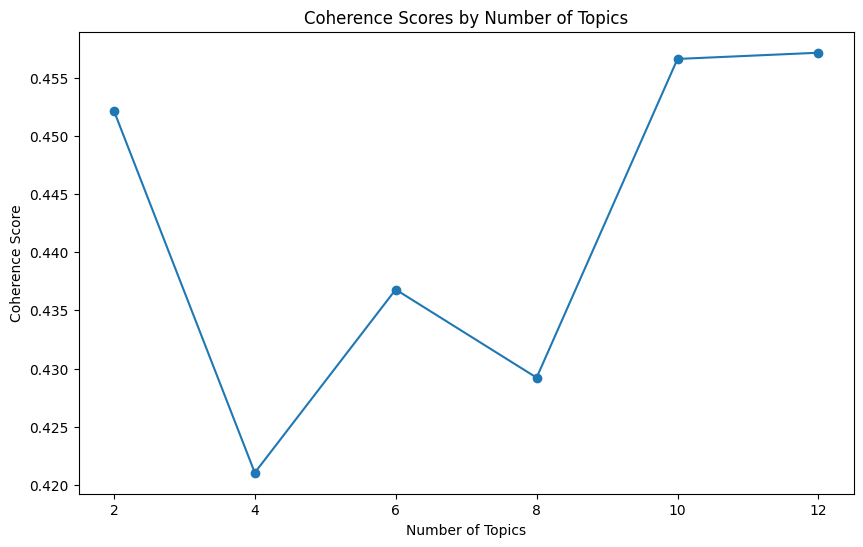

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(topics_range, coherence_scores, marker='o')
plt.title("Coherence Scores by Number of Topics")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.xticks(topics_range)
plt.savefig('lda_coherence_scores.png', dpi=150, bbox_inches='tight')
plt.show()

Choose 10 topics

In [29]:
# Find optimal number of topics
best_idx = np.argmax(coherence_scores)
OPTIMAL_NUM_TOPICS = list(topics_range)[best_idx-1]
best_score = coherence_scores[best_idx]

print(f"\n{'='*50}")
print(f"OPTIMAL NUMBER OF TOPICS: {OPTIMAL_NUM_TOPICS}")
print(f"Coherence Score: {best_score:.4f}")
print(f"{'='*50}")


OPTIMAL NUMBER OF TOPICS: 10
Coherence Score: 0.4571


Train final model of LDA for topic modeling

In [30]:
# Train final model with optimal number of topics
chunksize = 7000 # number of documents to be used in each training chunk
passes = 2 # epochs
iterations = 100 # how many times the model iterates over each document during a single pass / epoch
eval_every = 0  # affects speed and quality of the model, can increase for larger datasets

# Train final model
lda_model = LdaMulticore(
    corpus=corpus_LDA,
    id2word=dictionary,
    chunksize=chunksize,
    alpha="symmetric",
    eta='auto',
    iterations=iterations,
    num_topics=10,
    passes=passes,
    eval_every=eval_every,
    random_state=97,
    workers = multiprocessing.cpu_count() - 1 # Leave one core free for OS tasks
)

In [32]:
# Prepare the visualization
pyLDAvis.enable_notebook()
vis_data = gensimvis.prepare(lda_model, corpus_LDA, dictionary)
# display
pyLDAvis.display(vis_data)

In [35]:
# Print the top 10 words for each topic
topics = lda_model.print_topics(num_words=10)

for topic in topics:
    print(f"Topic {topic[0]}: {topic[1]}\n")

Topic 0: 0.014*"google" + 0.007*"model" + 0.005*"datum" + 0.005*"search" + 0.005*"feature" + 0.005*"patient" + 0.004*"machine" + 0.004*"year" + 0.004*"system" + 0.004*"time"

Topic 1: 0.008*"chatgpt" + 0.006*"like" + 0.005*"people" + 0.005*"year" + 0.005*"pay" + 0.004*"chatbot" + 0.004*"data" + 0.004*"time" + 0.004*"google" + 0.004*"tool"

Topic 2: 0.010*"model" + 0.007*"share" + 0.006*"nvidia" + 0.006*"datum" + 0.006*"market" + 0.005*"business" + 0.005*"chip" + 0.004*"year" + 0.004*"include" + 0.004*"openai"

Topic 3: 0.007*"2025" + 0.005*"video" + 0.005*"user" + 0.004*"feature" + 0.004*"2024" + 0.004*"2023" + 0.004*"world" + 0.003*"content" + 0.003*"tv" + 0.003*"time"

Topic 4: 0.009*"share" + 0.006*"business" + 0.006*"ago" + 0.006*"search" + 0.005*"video" + 0.005*"2023" + 0.004*"story" + 0.004*"weather" + 0.004*"email" + 0.004*"report"

Topic 5: 0.009*"image" + 0.008*"user" + 0.007*"tool" + 0.007*"content" + 0.007*"generate" + 0.007*"create" + 0.006*"model" + 0.006*"chatgpt" + 0.006

In [37]:
# Let's look at the first document in your corpus
doc_bow = corpus_LDA[0]

# Get the topic distribution for this document
topic_distribution = lda_model.get_document_topics(doc_bow)

print("Topic distribution for Document 0:")
for topic_num, probability in topic_distribution:
    print(f"Topic {topic_num}: {probability:.2%} match")

Topic distribution for Document 0:
Topic 9: 99.60% match


In [45]:
num_topics = lda_model.num_topics
words_per_topic = 20

for topic_id in range(num_topics):
    # Get the top words for this specific topic
    top_words_with_weights = lda_model.show_topic(topic_id, topn=words_per_topic)

    # Use a list comprehension to extract just the words, ignoring the weights
    word_list = [word for word, weight in top_words_with_weights]

    # Print a clean, comma-separated list
    print(f"Topic {topic_id}: {', '.join(word_list)}")

Topic 0: google, model, datum, search, feature, patient, machine, year, system, time, like, help, learning, work, health, base, artificial_intelligence, phone, power, gemini
Topic 1: chatgpt, like, people, year, pay, chatbot, data, time, google, tool, email, salary, report, human, help, artificial_intelligence, trump, share, write, work
Topic 2: model, share, nvidia, datum, market, business, chip, year, include, openai, chatgpt, report, product, user, industry, service, generative, billion, stock, platform
Topic 3: 2025, video, user, feature, 2024, 2023, world, content, tv, time, year, product, game, experience, share, like, service, power, include, business
Topic 4: share, business, ago, search, video, 2023, story, weather, email, report, facebook, 2024, microsoft, content, day, twitter, hour, world, openai, help
Topic 5: image, user, tool, content, generate, create, model, chatgpt, openai, video, generative, like, work, platform, 2023, time, human, help, generative_ai, include
Topic 

In [47]:
# 1. Create a dictionary mapping the topic numbers to your new human-readable names
topic_names = {
    0: "Health AI with Google Ecosystem",
    1: "AI Chatbots & the Workforce",
    2: "The impact of Nvidia and chips in stock market",
    3: "Digital Media & Entertainment",
    4: "Social Media & Tech News",
    5: "Generative AI Content Creation",
    6: "Tech & AI in the stock market",
    7: "Global AI Research & Development",
    8: "Enterprise Cloud & Data Solutions",
    9: "Cryptocurrency & Financial Trading"
}

# 2. Create an empty list to hold our data
document_topics_data = []

# 3. Loop through every document in your corpus
# (Make sure to use corpus_LDA or corpus_LDA_sample depending on what you trained on)
for i, doc_bow in enumerate(corpus_LDA):

    # Get the topic distribution for this specific document
    topic_distribution = lda_model.get_document_topics(doc_bow)

    # Find the tuple with the highest probability
    dominant_topic, highest_probability = max(topic_distribution, key=lambda x: x[1])

    # Store the results
    document_topics_data.append({
        'Document_Index': i,
        'Topic_Number': dominant_topic,
        'Topic_Name': topic_names.get(dominant_topic, "Unknown Topic"),
        'Probability': highest_probability
    })

# 4. Convert the list into a Pandas DataFrame
df_document_topics = pd.DataFrame(document_topics_data)

# Print the first 5 rows to verify
display(df_document_topics.head())

   Document_Index  Topic_Number  \
0               0             9   
1               1             3   
2               2             3   
3               3             8   
4               4             2   

                                       Topic_Name  Probability  
0              Cryptocurrency & Financial Trading     0.995980  
1                   Digital Media & Entertainment     0.974883  
2                   Digital Media & Entertainment     0.453399  
3               Enterprise Cloud & Data Solutions     0.481274  
4  The impact of Nvidia and chips in stock market     0.614109  


In [54]:
# Merge document topics and principal df_news_AI_clean
df_news_AI_clean['index'] = df_news_AI_clean.index
def_news_AI_clean_topics = pd.merge(df_news_AI_clean, df_document_topics, left_on='index', right_on='Document_Index', how='inner')
print('Initial df_news_AI_clean shape', df_news_AI_clean.shape)
print('def_news_AI_clean_topics shape', def_news_AI_clean_topics.shape)

Initial df_news_AI_clean shape (186029, 16)
def_news_AI_clean_topics shape (186029, 20)


In [55]:
def_news_AI_clean_topics.drop(columns=['index','Document_Index'], inplace=True)
display(def_news_AI_clean_topics.head())

,url,date,title,text,year,month,text_word_count,title_word_count,clean_title,clean_text,title_word_clean_count,text_word_clean_count,title_text_clean,title_text_clean_count,semantic_score,Topic_Number,Topic_Name,Probability
0,https://blockworks.co/price/bad,2025-06-23,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod...",2025,6,483,14,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",Open menuBrandsnewsletterspodcastseventsroundt...,12,470,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",482,0.205120,9,Cryptocurrency & Financial Trading,0.995980
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,This AI video of gymnastics might be the freak...,\n\nThis AI video of gymnastics might be the f...,2024,7,812,15,This AI video of gymnastics might be the freak...,"\nJennifer Sandlin\n5:13 am Mon\nJul 1, 2024\n...",12,724,This AI video of gymnastics might be the freak...,736,0.282888,3,Digital Media & Entertainment,0.974883
2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,"If using AI feels like a chore, try this - Boi...","\n\nIf using AI feels like a chore, try this -...",2024,9,884,12,"If using AI feels like a chore, try this","\nBoing Boing's Shop\n8:00 am Wed\nSep 18, 202...",9,802,"If using AI feels like a chore, try this \nBoi...",811,0.378478,3,Digital Media & Entertainment,0.453399
3,https://citylife.capetown/gl/uncategorized/the...,2023-11-10,The Road Ahead: How China's AI Foundation Mode...,The Road Ahead: How China's AI Foundation M...,2023,11,596,16,The Road Ahead: How China's AI Foundation Mode...,\nIr ao contidoVen. 10 de novembro de 2023 Vid...,16,580,The Road Ahead: How China's AI Foundation Mode...,596,0.449198,8,Enterprise Cloud & Data Solutions,0.481274
4,https://citylife.capetown/kk/uncategorized/mic...,2023-11-19,Microsoft and Nvidia to Empower Developers wit...,Microsoft and Nvidia to Empower Developers ...,2023,11,622,10,Microsoft and Nvidia to Empower Developers wit...,"\nByМамфо Брешиа\nҚараша 15, 2023\nMicrosoft a...",10,587,Microsoft and Nvidia to Empower Developers wit...,597,0.312896,2,The impact of Nvidia and chips in stock market,0.614109


In [61]:
display(def_news_AI_clean_topics['Topic_Name'].value_counts(normalize=False))
display(def_news_AI_clean_topics['Topic_Name'].value_counts(normalize=True))

,count
Topic_Name,
Enterprise Cloud & Data Solutions,33617
Global AI Research & Development,22677
Social Media & Tech News,20443
Generative AI Content Creation,19400
Digital Media & Entertainment,18186
AI Chatbots & the Workforce,17018
The impact of Nvidia and chips in stock market,15738
Health AI with Google Ecosystem,15101
Tech & AI in the stok market,14384


,proportion
Topic_Name,
Enterprise Cloud & Data Solutions,0.180708
Global AI Research & Development,0.121900
Social Media & Tech News,0.109891
Generative AI Content Creation,0.104285
Digital Media & Entertainment,0.097759
AI Chatbots & the Workforce,0.091480
The impact of Nvidia and chips in stock market,0.084600
Health AI with Google Ecosystem,0.081176
Tech & AI in the stok market,0.077321


Distribtuion of topics


,Topic_Name,count
0,Enterprise Cloud & Data Solutions,33617
1,Global AI Research & Development,22677
2,Social Media & Tech News,20443
3,Generative AI Content Creation,19400
4,Digital Media & Entertainment,18186
5,AI Chatbots & the Workforce,17018
6,The impact of Nvidia and chips in stock market,15738
7,Health AI with Google Ecosystem,15101
8,Tech & AI in the stok market,14384
9,Cryptocurrency & Financial Trading,9465


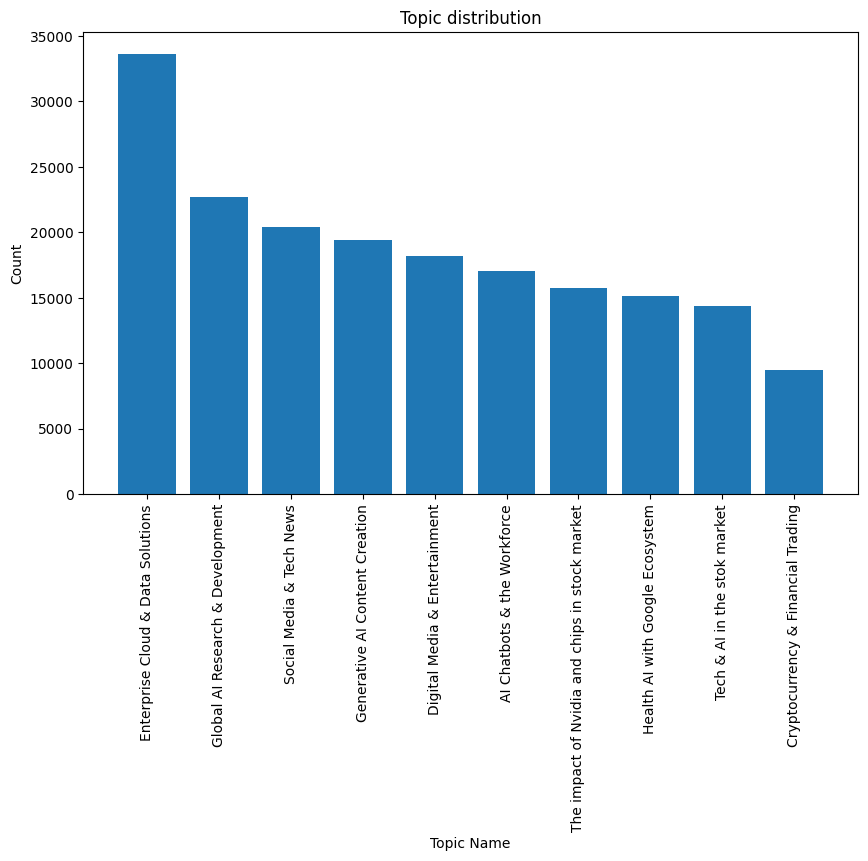

In [68]:
df_aux = def_news_AI_clean_topics['Topic_Name'].value_counts(normalize=False).reset_index()
print('Distribtuion of topics')
display(df_aux)
plt.figure(figsize=(10, 6))
plt.bar(df_aux['Topic_Name'], df_aux['count'])
plt.title("Topic distribution")
plt.xlabel("Topic Name")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [56]:
# Export consolidate parquet
file_path = "/content/drive/MyDrive/Colab Notebooks/Final Project NLP/def_news_AI_clean_topics.parquet"
def_news_AI_clean_topics.to_parquet(file_path, engine='auto')